# Dead-cat Bounce Range Audit

이 노트북은 `Dead-cat Bounce Range`를 **전략 진입 range로 직접 사용할 수 있는지**, 아니면 **시장 구조를 설명하는 진단용 레이어로 남겨야 하는지**를 실제 Binance BTCUSDT perpetual 체결 데이터로 확인한다.

핵심 질문은 다음과 같다.

1. 큰 하락 이후 반등 상단/저점은 의미 있는 가격 레벨을 만드는가?
2. 이 레벨을 그대로 박스권으로 사용하면 백테스트 성과가 좋아지는가?
3. 아니면 Price Box 전략에 대한 보조 진단 지표로만 쓰는 편이 더 안전한가?

> 결론을 먼저 말하면, 이 프로젝트에서는 Dead-cat range가 **진입 range로 직접 쓰기에는 stale level 문제가 있고**, Price Box 중심 전략의 **진단/설명 레이어**로 쓰는 편이 더 안정적이었다.

## 1. Concept: Dead-cat Bounce Range

Dead-cat Bounce Range는 큰 하락 이후 시장이 일시적으로 반등할 때 형성되는 **반등 상단**과 **저점 지지선**을 관찰하는 방법이다.

직관은 다음과 같다.

- 먼저 최근 고점 대비 충분히 큰 하락이 발생한 지점을 찾는다.
- 하락 이후 일정 시간 안에서 저점을 찾는다.
- 저점 이후 일정 시간 안에서 반등 고점을 찾는다.
- 이 반등 고점과 저점/다음 박스 상단을 임시 range로 본다.

다만 이 range는 실제 전략 진입선으로 오래 사용하면 위험할 수 있다. 하락 충격 이후 만들어진 레벨은 시장이 새로운 박스로 이동한 뒤에도 남아 있을 수 있기 때문이다.

### Detection Formula

자동 anchor 탐색에서는 현재 저가가 최근 고점 대비 충분히 많이 하락했는지 먼저 본다.

$$
DrawdownBps_t
=
\left(
\frac{Low_t}{\max(High_{t-L:t})}-1
\right)\times 10,000
$$

큰 하락 후보 조건은 다음과 같다.

$$
DrawdownBps_t \le -DropThresholdBps
$$

Anchor가 잡힌 뒤에는 `peak → trough → rebound high`를 요약한다.

$$
DropBps
=
\left(
\frac{TroughPrice}{PeakPrice}-1
\right)\times 10,000
$$

$$
ReboundBps
=
\left(
\frac{ReboundHigh}{TroughPrice}-1
\right)\times 10,000
$$

Dead-cat range로 인정하는 최소 조건은 다음과 같다.

$$
DropBps < 0
\quad \text{and} \quad
ReboundBps \ge MinReboundBps
$$

코드 위치:

- 자동 anchor 탐색: `research/microstructure_alpha/box_event_signals.py`, `detect_deadcat_bounce_ranges`
- peak/trough/rebound 요약: `research/microstructure_alpha/box_event_signals.py`, `_summarize_deadcat_event`
- 전략 range 반영: `research/microstructure_alpha/box_strategy_backtest.py`, `build_box_strategy_frame`

## 2. Setup

아래 셀은 프로젝트 루트를 자동으로 잡고, 실제 Binance trades parquet를 읽어 5분봉 OHLCV로 변환한다.

데이터 기본 경로는 다음과 같다.

`/Users/changminkim/Desktop/projects/equidice/datasets/exchange`

다른 환경에서 실행할 경우 `TAKORA_DATA_ROOT` 환경변수로 바꿀 수 있다.

In [1]:
from pathlib import Path
import os
import sys
from datetime import timedelta

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != 'takora-trading' and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_ROOT = Path(os.environ.get('TAKORA_DATA_ROOT', '/Users/changminkim/Desktop/projects/equidice/datasets/exchange'))
OUTPUT_DIR = PROJECT_ROOT / 'research/notebooks/_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

from research.microstructure_alpha.oi_box import detect_oi_box_ranges
from research.microstructure_alpha.box_event_signals import detect_deadcat_bounce_ranges
from research.microstructure_alpha.box_strategy_backtest import (
    BoxStrategyConfig,
    build_box_strategy_frame,
    candidate_box_strategy_configs,
    optimize_box_strategy,
    run_box_strategy_backtest,
)

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
plt.style.use('seaborn-v0_8-whitegrid')

PROJECT_ROOT, DATA_ROOT

(PosixPath('/Users/changminkim/Desktop/projects/equidice/takora-trading'),
 PosixPath('/Users/changminkim/Desktop/projects/equidice/datasets/exchange'))

## 3. Analysis Window

기본 분석 구간은 포트폴리오에서 사용한 진단 구간과 맞춘다.

- 시작: `2026-05-22 00:00:00`
- 종료: `2026-07-18 23:55:00`
- 봉: `5min`

구간을 바꾸고 싶으면 아래 `START_TIME`, `END_TIME`, `BAR_SIZE`만 수정하면 된다.

In [2]:
START_TIME = '2026-05-22 00:00:00'
END_TIME = '2026-07-18 23:55:00'
BAR_SIZE = '5m'
SYMBOL_PATH = 'binance/assets/btcusdt/future/trades/hour/*.parquet'

start_ts = pd.Timestamp(START_TIME)
end_ts = pd.Timestamp(END_TIME)
print(start_ts, '->', end_ts, BAR_SIZE)

2026-05-22 00:00:00 -> 2026-07-18 23:55:00 5m


## 4. Binance Trades Loader

원본 trades 데이터는 틱 단위라 크기가 크다. 따라서 Polars lazy scan으로 필요한 컬럼만 읽고, 바로 5분봉 OHLCV로 집계한다.

집계 결과:

- `open`: 첫 체결 가격
- `high`: 구간 최고 체결 가격
- `low`: 구간 최저 체결 가격
- `close`: 마지막 체결 가격
- `volume`: 체결 수량 합
- `trade_count`: 체결 건수

In [3]:
def date_filtered_paths(root: Path, pattern: str, start: pd.Timestamp, end: pd.Timestamp) -> list[Path]:
    paths = sorted(root.glob(pattern))
    dates = set(pd.date_range(start.normalize(), end.normalize(), freq='D').strftime('%Y-%m-%d'))
    selected = [path for path in paths if any(date in path.name for date in dates)]
    return selected


def load_binance_trades_ohlcv(
    *,
    data_root: Path = DATA_ROOT,
    pattern: str = SYMBOL_PATH,
    start: str | pd.Timestamp = START_TIME,
    end: str | pd.Timestamp = END_TIME,
    bar_size: str = BAR_SIZE,
) -> pd.DataFrame:
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)
    paths = date_filtered_paths(data_root, pattern, start, end)
    if not paths:
        raise FileNotFoundError(f'No parquet files found: {data_root / pattern}')

    lf = (
        pl.scan_parquet([str(path) for path in paths])
        .with_columns([
            pl.from_epoch(pl.col('trade_time'), time_unit='ms').alias('timestamp'),
            pl.col('price').cast(pl.Float64, strict=False).alias('price'),
            pl.col('quantity').cast(pl.Float64, strict=False).alias('quantity'),
        ])
        .filter(pl.col('timestamp') >= start.to_pydatetime())
        .filter(pl.col('timestamp') <= end.to_pydatetime())
        .drop_nulls(['timestamp', 'price', 'quantity'])
        .filter((pl.col('price') > 0) & (pl.col('quantity') > 0))
        .sort('timestamp')
        .group_by_dynamic('timestamp', every=bar_size, period=bar_size)
        .agg([
            pl.col('price').first().alias('open'),
            pl.col('price').max().alias('high'),
            pl.col('price').min().alias('low'),
            pl.col('price').last().alias('close'),
            pl.col('quantity').sum().alias('volume'),
            pl.len().alias('trade_count'),
        ])
    )
    out = lf.collect().to_pandas()
    out['timestamp'] = pd.to_datetime(out['timestamp']).astype('datetime64[ns]')
    out = out.dropna(subset=['open', 'high', 'low', 'close']).sort_values('timestamp').reset_index(drop=True)
    return out

price_df = load_binance_trades_ohlcv()
print('rows:', len(price_df))
print('range:', price_df['timestamp'].min(), '->', price_df['timestamp'].max())
price_df.head()

rows: 16703
range: 2026-05-22 00:00:00 -> 2026-07-18 23:50:00


,timestamp,open,high,low,close,volume,trade_count
0,2026-05-22 00:00:00,77586.3,77602.5,77480.0,77507.8,324.233,10270
1,2026-05-22 00:05:00,77507.9,77533.9,77497.5,77497.5,105.221,4533
2,2026-05-22 00:10:00,77497.5,77497.5,77405.4,77405.5,256.104,7238
3,2026-05-22 00:15:00,77405.4,77498.6,77374.4,77442.4,278.306,9473
4,2026-05-22 00:20:00,77442.3,77520.5,77441.2,77506.8,110.727,6209


## 5. Price Box Detection

Dead-cat range를 해석하려면 먼저 일반 Price Box가 필요하다. 여기서는 기존 박스권 탐지 함수를 그대로 사용한다.

Price Box는 특정 기간 동안 가격이 비교적 안정된 상단/하단 범위 안에 머무는지를 본다.

- `min_bars`: 최소 지속 길이
- `center_shift_bars`: 중심 이동을 확인하는 비교 구간
- `center_shift_ratio`: 중심이 기존 박스 폭 대비 얼마나 이동하면 다른 박스로 볼지
- `breakout_confirm_bars`: 이탈이 몇 개 봉 이상 지속되어야 박스 종료로 볼지

In [4]:
price_boxes = detect_oi_box_ranges(
    price_df,
    timestamp_col='timestamp',
    value_col='close',
    min_bars=72,
    center_shift_bars=48,
    center_shift_ratio=0.90,
    breakout_confirm_bars=6,
)

print('price boxes:', len(price_boxes))
box_preview = pd.DataFrame([box.__dict__ for box in price_boxes])
box_preview.head(10)

price boxes: 96


AttributeError: 'OIBox' object has no attribute '__dict__'

## 6. Dead-cat Bounce Range Detection

이 단계는 두 층으로 나뉜다.

1. **큰 하락 anchor 탐색**: 최근 고점 대비 일정 bps 이상 하락했는지 확인한다.
2. **반등 구조 요약**: anchor 이후 저점과 반등 고점을 찾고, 반등폭이 최소 기준 이상인지 확인한다.

여기서 중요한 점은 `drop_threshold_bps`와 `min_rebound_bps`의 역할이 다르다는 것이다.

- `drop_threshold_bps`: “큰 하락 후보인가?”를 찾는 앞단 필터
- `min_rebound_bps`: “하락 후 의미 있는 반등이 있었는가?”를 확인하는 뒷단 필터

In [5]:
deadcat_ranges = detect_deadcat_bounce_ranges(
    price_df,
    timestamp_col='timestamp',
    price_col='close',
    high_col='high',
    low_col='low',
    price_boxes=price_boxes,
    lookback_bars=288,          # 24h on 5m bars
    trough_search_bars=72,      # 6h
    rebound_bars=864,           # 3d
    drop_threshold_bps=350.0,   # recent high 대비 -3.5% 이상 하락
    min_rebound_bps=100.0,      # trough 이후 +1.0% 이상 반등
    cooldown_bars=288,
    box_match_tolerance='3h',
)

print('deadcat events:', len(deadcat_ranges))
summary_cols = [
    'event_time', 'peak_time', 'trough_time', 'rebound_high_time', 'range_end',
    'peak_price', 'trough_price', 'rebound_high', 'drop_bps', 'rebound_bps',
    'deadcat_upper', 'deadcat_lower', 'is_deadcat_range',
]
deadcat_ranges[summary_cols].head(20)

deadcat events: 19


,event_time,peak_time,trough_time,rebound_high_time,range_end,peak_price,trough_price,rebound_high,drop_bps,rebound_bps,deadcat_upper,deadcat_lower,is_deadcat_range
0,2026-05-23 07:50:00,2026-05-22 12:15:00,2026-05-23 08:40:00,2026-05-25 15:10:00,2026-05-26 08:35:00,77548.50,74307.00,77854.0,-417.996480,477.343992,74933.7400,74554.7100,True
1,2026-05-27 04:30:00,2026-05-26 14:25:00,2026-05-27 04:30:00,2026-05-27 12:20:00,2026-05-30 04:25:00,78077.10,75277.80,76155.5,-358.530222,116.594800,75962.1056,75332.6312,True
2,2026-05-28 04:30:00,2026-05-27 12:20:00,2026-05-28 06:35:00,2026-05-29 17:20:00,2026-05-31 06:30:00,76155.50,72729.20,74293.1,-449.908411,215.030552,73794.7232,72900.8968,True
3,2026-06-01 13:40:00,2026-05-31 23:00:00,2026-06-01 16:10:00,2026-06-01 17:50:00,2026-06-04 16:05:00,74179.90,70650.90,71788.5,-475.735341,161.017057,73181.2788,71631.9792,True
4,2026-06-02 13:40:00,2026-06-01 14:00:00,2026-06-02 19:30:00,2026-06-02 21:35:00,2026-06-05 19:25:00,71884.90,66388.00,67899.9,-764.680760,227.736940,69703.4328,67802.8080,True
5,2026-06-03 16:20:00,2026-06-02 16:20:00,2026-06-03 20:55:00,2026-06-03 21:45:00,2026-06-06 20:50:00,68072.90,64711.10,65829.4,-493.852914,172.814247,66100.6080,64420.1648,True
6,2026-06-04 16:20:00,2026-06-03 17:35:00,2026-06-04 17:45:00,2026-06-04 19:25:00,2026-06-07 17:40:00,66159.00,62910.00,64150.8,-491.089648,197.234144,64420.1648,62916.6440,True
7,2026-06-05 16:20:00,2026-06-04 19:25:00,2026-06-05 19:15:00,2026-06-07 22:15:00,2026-06-08 19:10:00,64150.80,59080.00,64250.0,-790.450002,875.084631,61553.8240,60339.5360,True
8,2026-06-09 14:10:00,2026-06-08 15:20:00,2026-06-09 16:40:00,2026-06-12 15:15:00,2026-06-12 16:35:00,64179.50,60755.00,64362.6,-533.581595,593.794749,61937.1592,61072.1008,True
9,2026-06-17 19:50:00,2026-06-17 16:25:00,2026-06-17 22:00:00,2026-06-18 01:10:00,2026-06-20 21:55:00,66445.93,63915.77,64780.0,-380.784798,135.213892,65841.5664,63061.4036,True


## 7. Visual Check: Peak → Trough → Rebound

아래 차트는 Dead-cat 이벤트를 가격 차트 위에 표시한다.

- 회색 음영: Price Box
- 빨간 세로선: 큰 하락 anchor
- 검정 점선: peak / trough / rebound high 시점
- 주황 수평선: deadcat upper
- 파란 수평선: deadcat lower

이 그림의 목적은 “반등 이후 생긴 레벨이 실제로 가격 구조를 설명하는가?”를 눈으로 확인하는 것이다.

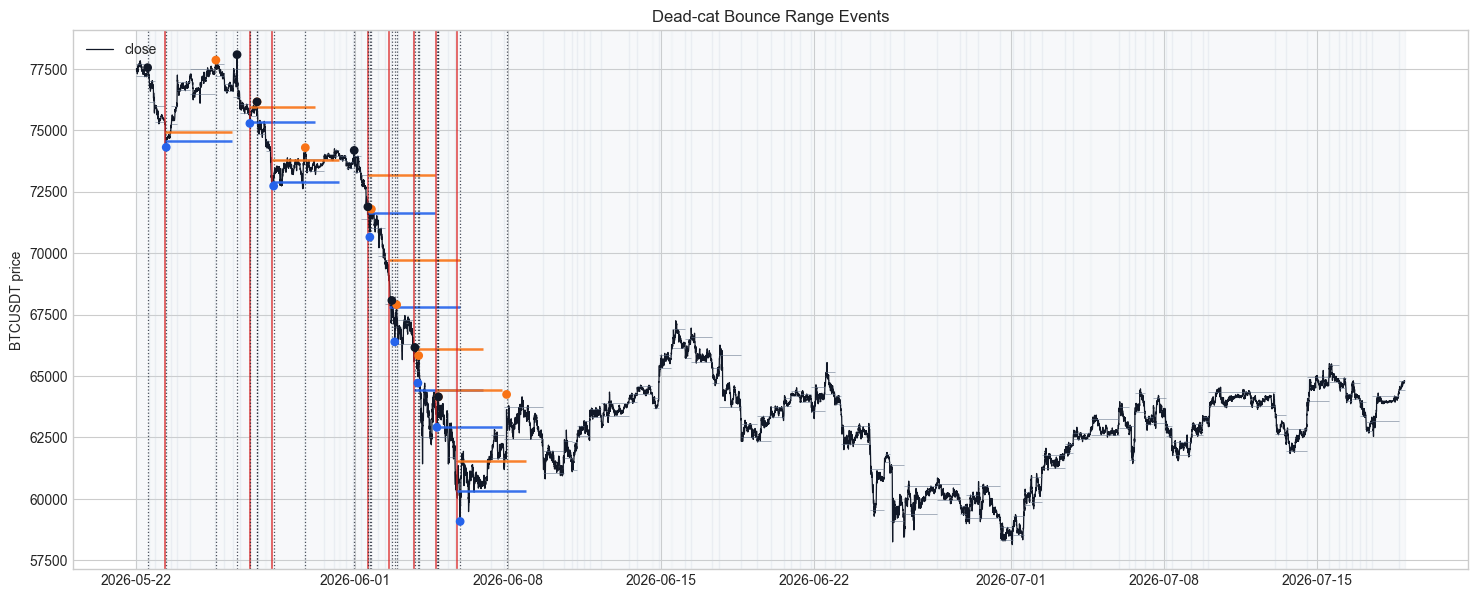

In [6]:
def plot_deadcat_events(
    price_frame: pd.DataFrame,
    price_boxes,
    deadcat_frame: pd.DataFrame,
    *,
    max_events: int = 8,
    title: str = 'Dead-cat Bounce Range Events',
):
    fig, ax = plt.subplots(figsize=(18, 7))
    ax.plot(price_frame['timestamp'], price_frame['close'], color='#111827', linewidth=0.9, label='close')

    for box in price_boxes:
        ax.axvspan(box.start, box.end, color='#CBD5E1', alpha=0.15)
        ax.hlines([box.low, box.high], box.start, box.end, color='#64748B', linewidth=0.7, alpha=0.55)

    events = deadcat_frame[deadcat_frame.get('is_deadcat_range', False) == True].head(max_events)
    for idx, row in events.iterrows():
        ax.axvline(row['event_time'], color='#DC2626', linestyle='-', linewidth=1.2, alpha=0.80)
        ax.axvline(row['peak_time'], color='#111827', linestyle=':', linewidth=0.9, alpha=0.75)
        ax.axvline(row['trough_time'], color='#111827', linestyle=':', linewidth=0.9, alpha=0.75)
        ax.axvline(row['rebound_high_time'], color='#111827', linestyle=':', linewidth=0.9, alpha=0.75)
        ax.hlines(row['deadcat_upper'], row['event_time'], row['range_end'], color='#F97316', linewidth=1.8, alpha=0.90)
        ax.hlines(row['deadcat_lower'], row['event_time'], row['range_end'], color='#2563EB', linewidth=1.8, alpha=0.90)
        ax.scatter([row['peak_time'], row['trough_time'], row['rebound_high_time']],
                   [row['peak_price'], row['trough_price'], row['rebound_high']],
                   s=28, color=['#111827', '#2563EB', '#F97316'], zorder=4)

    ax.set_title(title)
    ax.set_ylabel('BTCUSDT price')
    ax.legend(loc='upper left')
    return fig, ax

fig, ax = plot_deadcat_events(price_df, price_boxes, deadcat_ranges, max_events=8)
plt.show()

## 8. Visual Check: Drop / Rebound Bps

Dead-cat 이벤트마다 실제 낙폭과 반등폭을 bps 단위로 확인한다.

이 차트에서는 다음을 본다.

- 낙폭이 충분히 큰 이벤트만 anchor로 잡혔는가?
- 반등폭이 최소 기준 이상인 이벤트만 Dead-cat range로 인정되는가?
- 반등이 너무 작거나 너무 늦은 이벤트는 전략 레벨로 쓰기 애매하지 않은가?

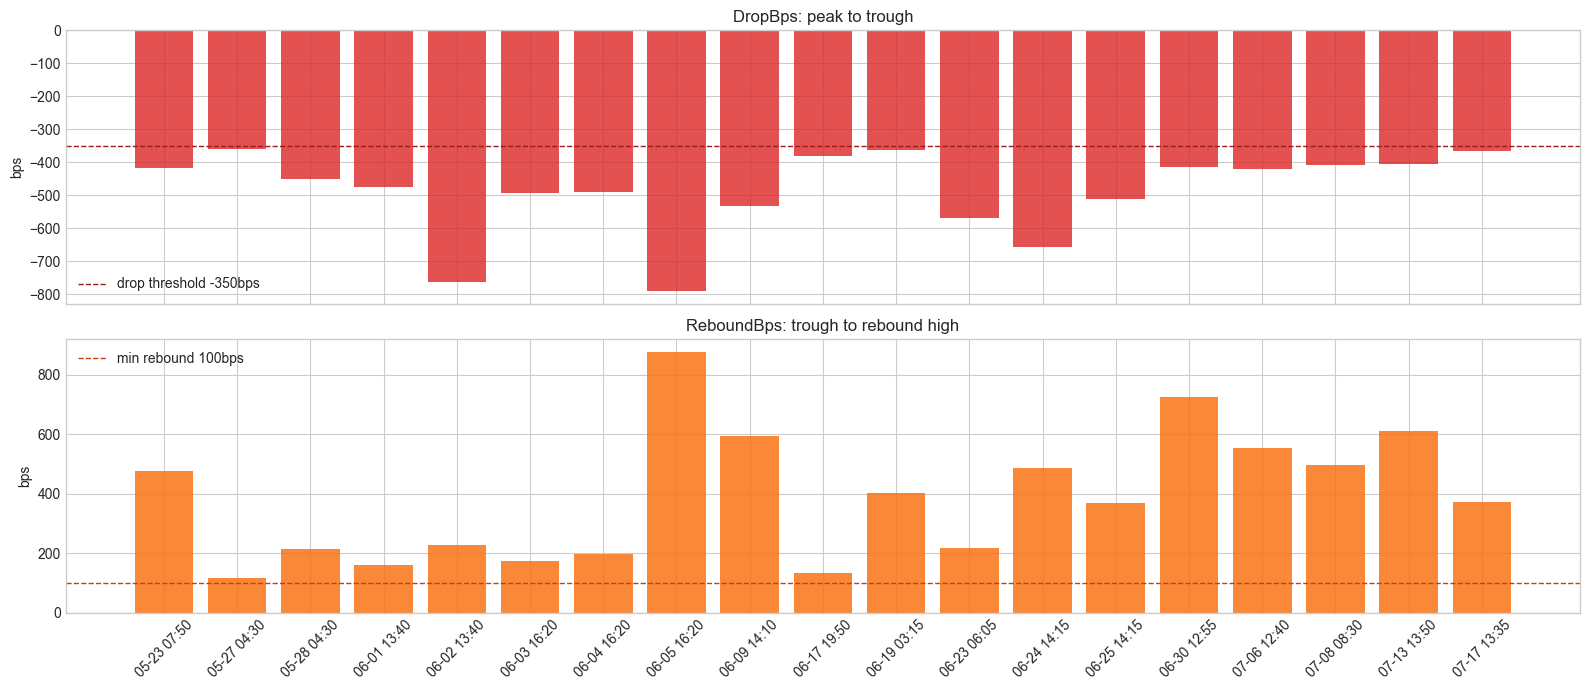

In [7]:
if deadcat_ranges.empty:
    print('No dead-cat ranges detected. Try lowering drop_threshold_bps or extending the time window.')
else:
    plot_df = deadcat_ranges.copy()
    plot_df['event_label'] = plot_df['event_time'].dt.strftime('%m-%d %H:%M')
    fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
    axes[0].bar(plot_df['event_label'], plot_df['drop_bps'], color='#DC2626', alpha=0.80)
    axes[0].axhline(-350, color='#991B1B', linestyle='--', linewidth=1, label='drop threshold -350bps')
    axes[0].set_title('DropBps: peak to trough')
    axes[0].set_ylabel('bps')
    axes[0].legend(loc='lower left')

    colors = np.where(plot_df['is_deadcat_range'], '#F97316', '#94A3B8')
    axes[1].bar(plot_df['event_label'], plot_df['rebound_bps'], color=colors, alpha=0.85)
    axes[1].axhline(100, color='#C2410C', linestyle='--', linewidth=1, label='min rebound 100bps')
    axes[1].set_title('ReboundBps: trough to rebound high')
    axes[1].set_ylabel('bps')
    axes[1].legend(loc='upper left')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

## 9. Backtest Design

여기서는 Dead-cat range의 역할을 직접 비교한다.

### Scenario A: Dead-cat as range

Dead-cat upper/lower를 실제 `active_range`로 사용한다. 즉, 하락 후 생긴 반등 상단/저점을 진입 range로 취급한다.

### Scenario B: Price box only

Dead-cat range는 진단용으로만 보고, 실제 진입 range는 Price Box만 사용한다.

두 시나리오는 같은 비용과 리스크 관리 조건을 사용한다.

- fee: 4 bps
- slippage: 2 bps
- spread: 1 bps
- stop-distance 기반 position sizing
- Long/Short geometry check: Long은 `SL < Entry < TP`, Short은 `TP < Entry < SL`일 때만 진입

In [8]:
base_config = BoxStrategyConfig(
    entry_edge_ratio=0.08,
    bounce_confirm_bps=3.0,
    trailing_stop_bps=220.0,
    range_stop_buffer_bps=60.0,
    risk_per_trade=0.0015,
    max_leverage=0.70,
    max_holding_bars=288,
    allow_short=True,
    fee_bps=4.0,
    slippage_bps=2.0,
    spread_bps=1.0,
)

candidate_configs = candidate_box_strategy_configs(
    base_config,
    entry_edge_ratios=(0.06, 0.08, 0.12, 0.18),
    bounce_confirm_bps_values=(0.0, 3.0, 8.0),
    trailing_stop_bps_values=(160.0, 220.0),
    range_stop_buffer_bps_values=(60.0, 110.0),
    risk_per_trade_values=(0.0015,),
)
print('candidate configs:', len(candidate_configs))

candidate configs: 48


In [9]:
def make_empty_events() -> tuple[pd.DataFrame, pd.DataFrame]:
    return pd.DataFrame(), pd.DataFrame()


def build_frame_for_scenario(use_deadcat_range: bool, config: BoxStrategyConfig) -> pd.DataFrame:
    terminal, transient = make_empty_events()
    return build_box_strategy_frame(
        price_frame=price_df,
        price_boxes=price_boxes,
        deadcat_bounce_ranges=deadcat_ranges if use_deadcat_range else pd.DataFrame(),
        terminal_oi_volatility=terminal,
        transient_oi_shocks=transient,
        timestamp_col='timestamp',
        price_col='close',
        high_col='high',
        low_col='low',
        config=config,
    )


def run_scenario(name: str, use_deadcat_range: bool):
    frame = build_frame_for_scenario(use_deadcat_range, base_config)
    result, report = optimize_box_strategy(
        frame,
        candidate_configs=candidate_configs,
        timestamp_col='timestamp',
        price_col='close',
        high_col='high',
        low_col='low',
        min_win_rate=0.50,
        min_total_return=0.0,
        min_trades=5,
    )
    metrics = result.metrics.copy()
    row = {
        'scenario': name,
        'uses_deadcat_range': use_deadcat_range,
        'passes_constraints': result.passes_constraints,
        'total_return_pct': metrics.get('total_return', np.nan) * 100,
        'win_rate_pct': metrics.get('win_rate', np.nan) * 100,
        'profit_factor': metrics.get('profit_factor', np.nan),
        'max_drawdown_pct': metrics.get('max_drawdown', np.nan) * 100,
        'total_trades': metrics.get('total_trades', np.nan),
    }
    return row, result, report

scenario_rows = []
scenario_results = {}
scenario_reports = {}

for name, use_deadcat in [
    ('deadcat_as_range', True),
    ('price_box_only', False),
]:
    row, result, report = run_scenario(name, use_deadcat)
    scenario_rows.append(row)
    scenario_results[name] = result
    scenario_reports[name] = report

result_summary = pd.DataFrame(scenario_rows)
result_summary

,scenario,uses_deadcat_range,passes_constraints,total_return_pct,win_rate_pct,profit_factor,max_drawdown_pct,total_trades
0,deadcat_as_range,True,False,-1.566131,33.486239,0.872145,-3.192485,218.0
1,price_box_only,False,True,14.564312,74.703557,2.623193,-0.751391,253.0


## 10. Backtest Result Visualization

아래 차트는 두 시나리오의 핵심 성과를 비교한다.

해석 포인트는 단순하다.

- Dead-cat을 직접 range로 쓰면 거래 수가 늘어날 수 있지만, 오래된 레벨이 현재 시장 상태와 맞지 않을 수 있다.
- Price Box만 사용하면 진입 기준은 단순하지만, 현재 시장의 박스 구조에 더 직접적으로 맞는다.
- 따라서 Dead-cat은 “거래 신호”가 아니라 “하락 후 형성된 레벨을 해석하는 보조 정보”로 두는 편이 더 낫다.

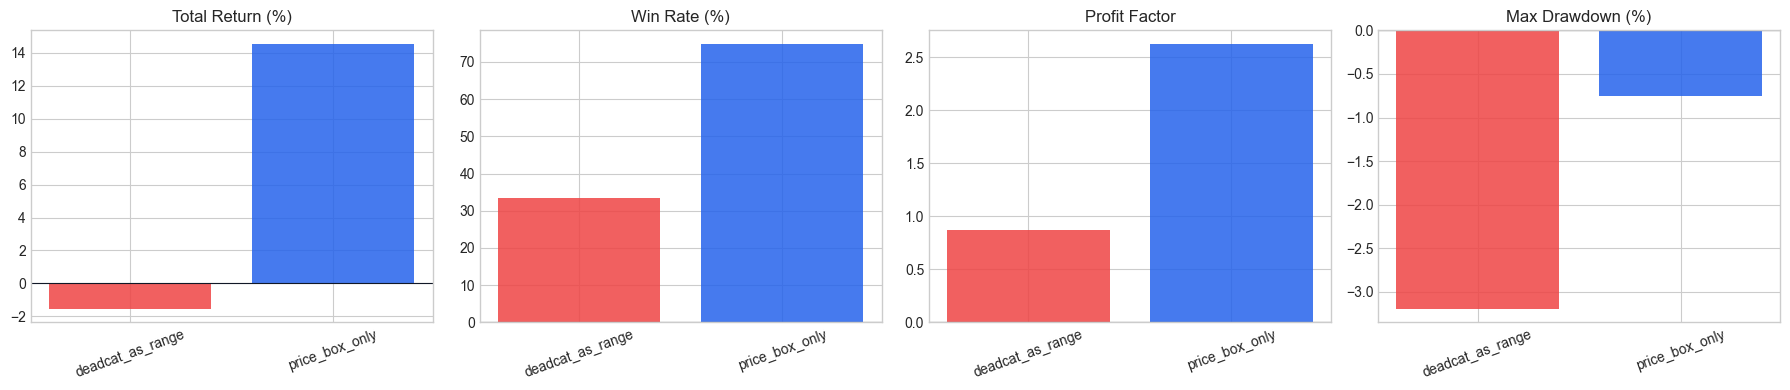

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
metrics_to_plot = [
    ('total_return_pct', 'Total Return (%)'),
    ('win_rate_pct', 'Win Rate (%)'),
    ('profit_factor', 'Profit Factor'),
    ('max_drawdown_pct', 'Max Drawdown (%)'),
]
colors = ['#EF4444' if s == 'deadcat_as_range' else '#2563EB' for s in result_summary['scenario']]

for ax, (col, title) in zip(axes, metrics_to_plot):
    ax.bar(result_summary['scenario'], result_summary[col], color=colors, alpha=0.85)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)
    ax.axhline(0, color='#111827', linewidth=0.8)

plt.tight_layout()
plt.show()

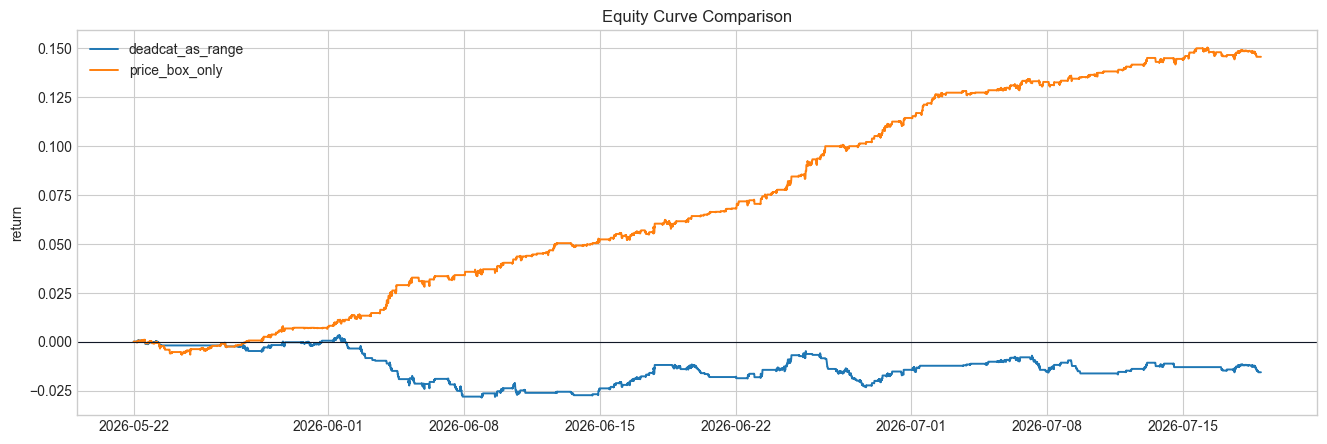

In [11]:
fig, ax = plt.subplots(figsize=(16, 5))
for name, result in scenario_results.items():
    curve = result.equity_curve.copy()
    if curve.empty:
        continue
    initial = curve['equity'].iloc[0]
    ax.plot(curve['timestamp'], curve['equity'] / initial - 1.0, label=name, linewidth=1.4)
ax.axhline(0, color='#111827', linewidth=0.8)
ax.set_title('Equity Curve Comparison')
ax.set_ylabel('return')
ax.legend()
plt.show()

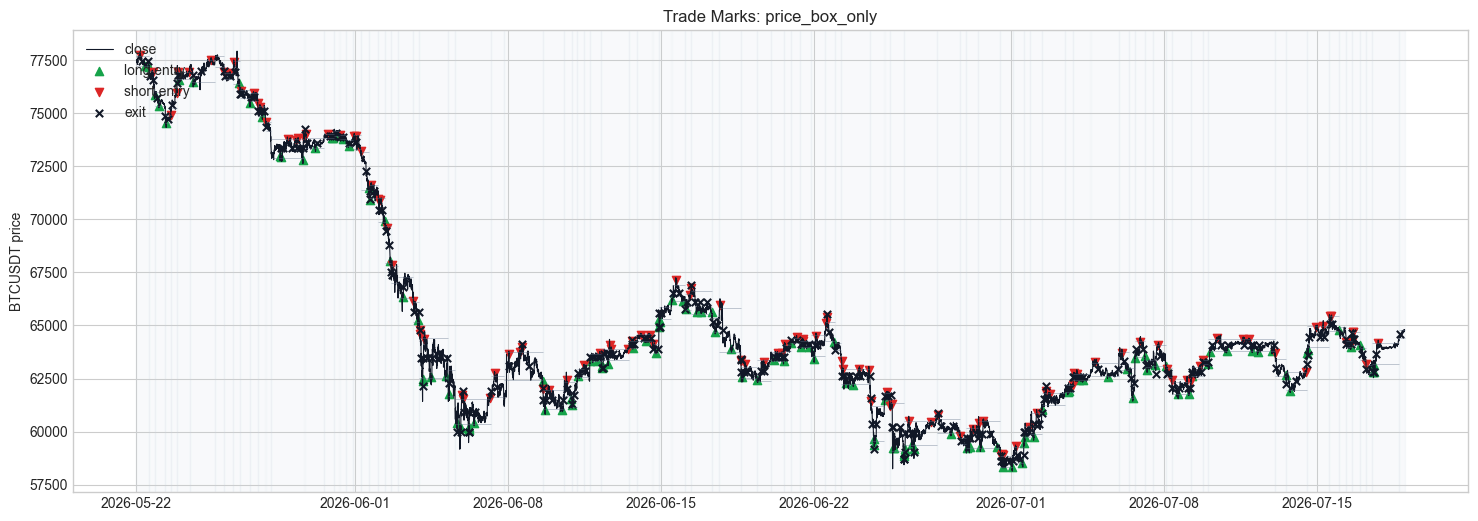

In [12]:
def plot_trade_marks(result, title: str):
    trades = result.trades.copy()
    fig, ax = plt.subplots(figsize=(18, 6))
    ax.plot(price_df['timestamp'], price_df['close'], color='#111827', linewidth=0.8, label='close')

    for box in price_boxes:
        ax.axvspan(box.start, box.end, color='#CBD5E1', alpha=0.12)
        ax.hlines([box.low, box.high], box.start, box.end, color='#64748B', linewidth=0.6, alpha=0.45)

    if not trades.empty:
        long_entries = trades[trades['direction'] > 0]
        short_entries = trades[trades['direction'] < 0]
        ax.scatter(long_entries['entry_time'], long_entries['entry_price'], marker='^', s=35, color='#16A34A', label='long entry')
        ax.scatter(short_entries['entry_time'], short_entries['entry_price'], marker='v', s=35, color='#DC2626', label='short entry')
        ax.scatter(trades['exit_time'], trades['exit_price'], marker='x', s=28, color='#111827', label='exit')

    ax.set_title(title)
    ax.set_ylabel('BTCUSDT price')
    ax.legend(loc='upper left')
    return fig, ax

best_name = 'price_box_only' if 'price_box_only' in scenario_results else next(iter(scenario_results))
fig, ax = plot_trade_marks(scenario_results[best_name], f'Trade Marks: {best_name}')
plt.show()

## 11. Why Dead-cat Is Diagnostic, Not Main Range

`build_box_strategy_frame`에서는 Dead-cat range가 들어오면 다음처럼 `active_range`에 먼저 반영된다.

$$
ActiveRangeLow_t = DeadcatLower_t \; \text{if exists, else} \; PriceBoxLow_t
$$

$$
ActiveRangeHigh_t = DeadcatUpper_t \; \text{if exists, else} \; PriceBoxHigh_t
$$

이 구조는 실험에는 유용하지만, 실제 전략 관점에서는 주의가 필요하다.

Dead-cat level은 **하락 충격 이후 만들어진 가격 기억**에 가깝다. 따라서 시간이 지나 새로운 박스가 만들어졌는데도 과거 Dead-cat range가 계속 남아 있으면, 현재 시장의 박스가 아니라 과거 충격의 잔상으로 거래하게 된다.

이 노트북의 핵심 판단:

- Dead-cat range는 큰 하락 후 시장이 어디까지 반등했는지 설명하는 데 유용하다.
- 하지만 이를 직접 진입 range로 쓰면 stale level 문제가 발생할 수 있다.
- 따라서 최종 전략에서는 Price Box를 주 range로 사용하고, Dead-cat은 진단/해석 레이어로 남긴다.

In [13]:
# Optional: inspect top configs for each scenario.
for name, report in scenario_reports.items():
    print('\n===', name, 'top configs ===')
    display_cols = [
        'passes_constraints', 'entry_edge_ratio', 'bounce_confirm_bps', 'trailing_stop_bps',
        'range_stop_buffer_bps', 'risk_per_trade', 'total_return', 'win_rate',
        'profit_factor', 'max_drawdown', 'total_trades',
    ]
    available = [col for col in display_cols if col in report.columns]
    display(report[available].head(10))


=== deadcat_as_range top configs ===


,passes_constraints,entry_edge_ratio,bounce_confirm_bps,trailing_stop_bps,range_stop_buffer_bps,risk_per_trade,total_return,win_rate,profit_factor,max_drawdown,total_trades
0,False,0.08,8.0,160.0,60.0,0.0015,-0.015661,0.334862,0.872145,-0.031925,218.0
1,False,0.08,8.0,220.0,60.0,0.0015,-0.015661,0.334862,0.872145,-0.031925,218.0
2,False,0.06,8.0,160.0,60.0,0.0015,-0.019091,0.307317,0.836660,-0.031925,205.0
3,False,0.06,8.0,220.0,60.0,0.0015,-0.019091,0.307317,0.836660,-0.031925,205.0
4,False,0.12,8.0,160.0,60.0,0.0015,-0.020387,0.368201,0.845955,-0.034768,239.0
5,False,0.12,8.0,220.0,60.0,0.0015,-0.020387,0.368201,0.845955,-0.034768,239.0
6,False,0.08,3.0,160.0,60.0,0.0015,-0.021751,0.348485,0.847320,-0.034346,264.0
7,False,0.08,3.0,220.0,60.0,0.0015,-0.021751,0.348485,0.847320,-0.034346,264.0
8,False,0.06,3.0,160.0,60.0,0.0015,-0.028895,0.310484,0.792447,-0.035796,248.0
9,False,0.06,3.0,220.0,60.0,0.0015,-0.028895,0.310484,0.792447,-0.035796,248.0



=== price_box_only top configs ===


,passes_constraints,entry_edge_ratio,bounce_confirm_bps,trailing_stop_bps,range_stop_buffer_bps,risk_per_trade,total_return,win_rate,profit_factor,max_drawdown,total_trades
0,True,0.08,3.0,160.0,60.0,0.0015,0.145643,0.747036,2.623193,-0.007514,253.0
1,True,0.08,3.0,220.0,60.0,0.0015,0.145643,0.747036,2.623193,-0.007514,253.0
2,True,0.08,8.0,160.0,60.0,0.0015,0.140559,0.753623,2.953496,-0.004545,207.0
3,True,0.08,8.0,220.0,60.0,0.0015,0.140559,0.753623,2.953496,-0.004545,207.0
4,True,0.08,0.0,160.0,60.0,0.0015,0.140301,0.739583,2.309532,-0.007427,288.0
5,True,0.08,0.0,220.0,60.0,0.0015,0.140301,0.739583,2.309532,-0.007427,288.0
6,True,0.12,8.0,160.0,60.0,0.0015,0.135536,0.756198,2.605512,-0.006948,242.0
7,True,0.12,8.0,220.0,60.0,0.0015,0.135536,0.756198,2.605512,-0.006948,242.0
8,True,0.12,3.0,160.0,60.0,0.0015,0.133858,0.746667,2.267433,-0.007568,300.0
9,True,0.12,3.0,220.0,60.0,0.0015,0.133858,0.746667,2.267433,-0.007568,300.0
